# Part 4 Analysis of Aviation Accidents

This notebook addresses **Part 4** of the project using the provided `aviation_accident.csv` dataset in the current working directory.

The workflow is intentionally broad:

- explore the data structure and quality,
- identify accident trends over time,
- compute and visualize survival-rate patterns,
- examine the phases of flight, weather, damage, and operational context,
- and fit a regression model that uses **all applicable features** without obvious leakage.

The notebook is written to be readable as a report and also executable as a standalone analysis file.


## 1. Objectives and analysis plan

The project prompt asks for three broad outcomes:

1. **Describe the dataset and report key observations**.
2. **Study accident trends over time** and identify the most dangerous phases of flight.
3. **Fit a regression model** using as many applicable features as possible, while avoiding overfitting through cross-validation or related safeguards.

To keep the analysis disciplined, this notebook separates the work into two layers:

- **Descriptive analysis**: accident counts, survival rates, damage levels, weather, phase of flight, and other operational patterns.
- **Predictive modeling**: a cross-validated regression model for accident severity using a survival-rate target and all reasonable pre-accident / contextual predictors.

That separation matters because some columns are useful for interpretation but would create leakage if used as predictors for accident severity.


In [3]:
# Standard imports
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import GridSearchCV, GroupKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import statsmodels.api as sm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)
pd.reset_option('display.float_format')

print('Imports loaded successfully.')


Imports loaded successfully.


In [4]:
# Load the dataset from the current working directory.
# The file is intentionally not hard-coded with an absolute path so the notebook remains portable.
data_path = 'aviation_accident.csv'
df = pd.read_csv(data_path, low_memory=False)

# Standardize column names to snake_case so the rest of the notebook is easier to read.
df = df.rename(columns=lambda col: col.strip().replace('.', '_'))

# Keep source Year as an integer so displays show 1982 instead of 1982.0.
if 'Year' in df.columns:
    df['Year'] = pd.to_numeric(df['Year'], errors='coerce').astype('Int64')

print('Shape:', df.shape)
display(df.head())


Shape: (68565, 31)


,Event_Id,Investigation_Type,Accident_Number,Event_Date,Location,Country,Airport_Code,Airport_Name,Injury_Severity,Aircraft_damage,Registration_Number,Make,Model,Amateur_Built,Number_of_Engines,Engine_Type,Purpose_of_flight,Total_Fatal_Injuries,Total_Serious_Injuries,Total_Minor_Injuries,Total_Uninjured,Weather_Condition,Broad_phase_of_flight,Report_Status,Publication_Date,Year,Month_Abbr,Day_Name_Abbr,Weekend,City,State
0,20020909X01562,Accident,SEA82DA022,1982-01-01,"PULLMAN, WA",United States,NaN,BLACKBURN AG STRIP,Non-Fatal,Substantial,N2482N,Cessna,140,False,1.0,Reciprocating,Personal,0.0,0.0,0.0,2.0,VMC,Takeoff,Probable Cause,01-01-1982,1982,Jan,Fri,False,PULLMAN,WA
1,20020909X01561,Accident,NYC82DA015,1982-01-01,"EAST HANOVER, NJ",United States,N58,HANOVER,Non-Fatal,Substantial,N7967Q,Cessna,401B,False,2.0,Reciprocating,Business,0.0,0.0,0.0,2.0,IMC,Landing,Probable Cause,01-01-1982,1982,Jan,Fri,False,EAST HANOVER,NJ
2,20020909X01560,Accident,MIA82DA029,1982-01-01,"JACKSONVILLE, FL",United States,JAX,JACKSONVILLE INTL,Non-Fatal,Substantial,N3906K,North American,NAVION L-17B,False,1.0,Reciprocating,Personal,0.0,0.0,3.0,0.0,IMC,Cruise,Probable Cause,01-01-1982,1982,Jan,Fri,False,JACKSONVILLE,FL
3,20020909X01559,Accident,FTW82DA034,1982-01-01,"HOBBS, NM",United States,NaN,NaN,Non-Fatal,Substantial,N44832,Piper,PA-28-161,False,1.0,Reciprocating,Personal,0.0,0.0,0.0,1.0,VMC,Approach,Probable Cause,01-01-1982,1982,Jan,Fri,False,HOBBS,NM
4,20020909X01558,Accident,ATL82DKJ10,1982-01-01,"TUSKEGEE, AL",United States,NaN,TUSKEGEE,Non-Fatal,Substantial,N4275S,Beech,V35B,False,1.0,Reciprocating,Personal,0.0,0.0,0.0,1.0,VMC,Landing,Probable Cause,01-01-1982,1982,Jan,Fri,False,TUSKEGEE,AL


In [5]:
# Basic cleaning and feature engineering.
# The goal here is to create analysis-ready fields while preserving the original data.

# Parse dates.
df['Event_Date'] = pd.to_datetime(df['Event_Date'], errors='coerce')
df['Publication_Date'] = pd.to_datetime(df['Publication_Date'], errors='coerce', dayfirst=True)

# Normalize text columns for consistent grouping.
text_columns = [
    'Investigation_Type', 'Location', 'Country', 'Airport_Code', 'Airport_Name',
    'Injury_Severity', 'Aircraft_damage', 'Registration_Number', 'Make', 'Model',
    'Amateur_Built', 'Engine_Type', 'Purpose_of_flight', 'Weather_Condition',
    'Broad_phase_of_flight', 'Report_Status', 'Month_Abbr', 'Day_Name_Abbr', 'Weekend',
    'City', 'State'
]
for col in text_columns:
    if col in df.columns:
        df[col] = df[col].astype('string').str.strip().fillna('Unknown')

# Ensure injury count columns are numeric before aggregation.
injury_cols = ['Total_Fatal_Injuries', 'Total_Serious_Injuries', 'Total_Minor_Injuries', 'Total_Uninjured']
for col in injury_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Create a usable total-occupant count from the injury columns.
df['Total_Occupants_Known'] = df[injury_cols].sum(axis=1, min_count=1)

# Survivors include serious injuries, minor injuries, and uninjured occupants.
# Survival rate = survivors / total occupants with known injury counts.
survivor_cols = ['Total_Serious_Injuries', 'Total_Minor_Injuries', 'Total_Uninjured']
df['Total_Survivors_Known'] = df[survivor_cols].sum(axis=1, min_count=1)

df['Survival_Rate'] = np.where(
    df['Total_Occupants_Known'].gt(0),
    df['Total_Survivors_Known'] / df['Total_Occupants_Known'],
    np.nan
)
df['Survival_Rate'] = df['Survival_Rate'].clip(0, 1)

# Fatality rate is the complement of survival rate when totals are known.
df['Fatality_Rate'] = np.where(
    df['Total_Occupants_Known'].gt(0),
    df['Total_Fatal_Injuries'] / df['Total_Occupants_Known'],
    np.nan
)
df['Fatality_Rate'] = df['Fatality_Rate'].clip(0, 1)

# A simple ordered damage score is useful for descriptive work.
damage_map = {'Minor': 0, 'Substantial': 1, 'Destroyed': 2}
df['Damage_Severity_Score'] = df['Aircraft_damage'].map(damage_map)

# Convenience date features.
df['Accident_Year'] = df['Event_Date'].dt.year.astype('Int64')
df['Accident_Month'] = df['Event_Date'].dt.month_name()
df['Accident_Day_of_Week'] = df['Event_Date'].dt.day_name()

# A few quality flags help quantify how much usable data we have.
df['Has_Survival_Rate'] = df['Survival_Rate'].notna()
df['Has_Phase'] = df['Broad_phase_of_flight'].ne('Unknown')

print('Columns after cleaning:', len(df.columns))
display(df[['Event_Date', 'Accident_Year', 'Accident_Month', 'Accident_Day_of_Week', 'Survival_Rate', 'Fatality_Rate', 'Damage_Severity_Score']].head())


Columns after cleaning: 41


,Event_Date,Accident_Year,Accident_Month,Accident_Day_of_Week,Survival_Rate,Fatality_Rate,Damage_Severity_Score
0,1982-01-01,1982,January,Friday,1.0,0.0,1.0
1,1982-01-01,1982,January,Friday,1.0,0.0,1.0
2,1982-01-01,1982,January,Friday,1.0,0.0,1.0
3,1982-01-01,1982,January,Friday,1.0,0.0,1.0
4,1982-01-01,1982,January,Friday,1.0,0.0,1.0


## 2. Data quality and usable fields

Before making any conclusions, it is useful to check which fields are mostly populated and which are sparse.

This step matters for two reasons:

- it explains why some variables are better used descriptively than as model inputs,
- and it helps justify the feature-selection choices used in the regression model later.

High-cardinality columns such as `Make`, `Model`, `Airport_Name`, and `City` are not discarded simply because they are large. Instead, they are kept and handled with rare-category grouping in the model pipeline so they still contribute useful signal without exploding the design matrix.


In [20]:
# Missingness summary and a quick look at cardinality for the most important fields.
missing_pct = (df.isna().mean().sort_values(ascending=False) * 100).round(2)
display(missing_pct.to_frame('Missing %'))

summary_cols = [
    'Injury_Severity', 'Aircraft_damage', 'Weather_Condition', 'Broad_phase_of_flight',
    'Purpose_of_flight', 'Engine_Type', 'Amateur_Built', 'Country', 'State',
    'Airport_Code', 'Airport_Name', 'Make', 'Model', 'City'
]
cardinality = df[summary_cols].nunique(dropna=True).sort_values(ascending=False)
display(cardinality.to_frame('Unique values'))

print('Rows with a computable survival rate:', int(df['Has_Survival_Rate'].sum()))
print('Rows with a known phase of flight:', int(df['Has_Phase'].sum()))


,Missing %
Publication_Date,22.01
Number_of_Engines,4.47
Year,4.19
Damage_Severity_Score,3.51
Fatality_Rate,2.20
Survival_Rate,2.20
Total_Fatal_Injuries,2.10
Event_Date,2.10
Event_Id,2.10
Accident_Month,2.10


,Unique values
Airport_Name,20231
City,15876
Airport_Code,9876
Model,9581
Make,6165
State,67
Purpose_of_flight,25
Broad_phase_of_flight,12
Engine_Type,11
Injury_Severity,5


Rows with a computable survival rate: 67058
Rows with a known phase of flight: 46118


## 3. Accident trends over time

A core descriptive question is whether accident frequency changes over time.

The plot below shows accident counts by year. A second panel shows the average survival rate by year, which gives a rough sense of how the severity mix changes over time.

Note that this does **not** imply causality; it is a descriptive trend check, not a causal model.


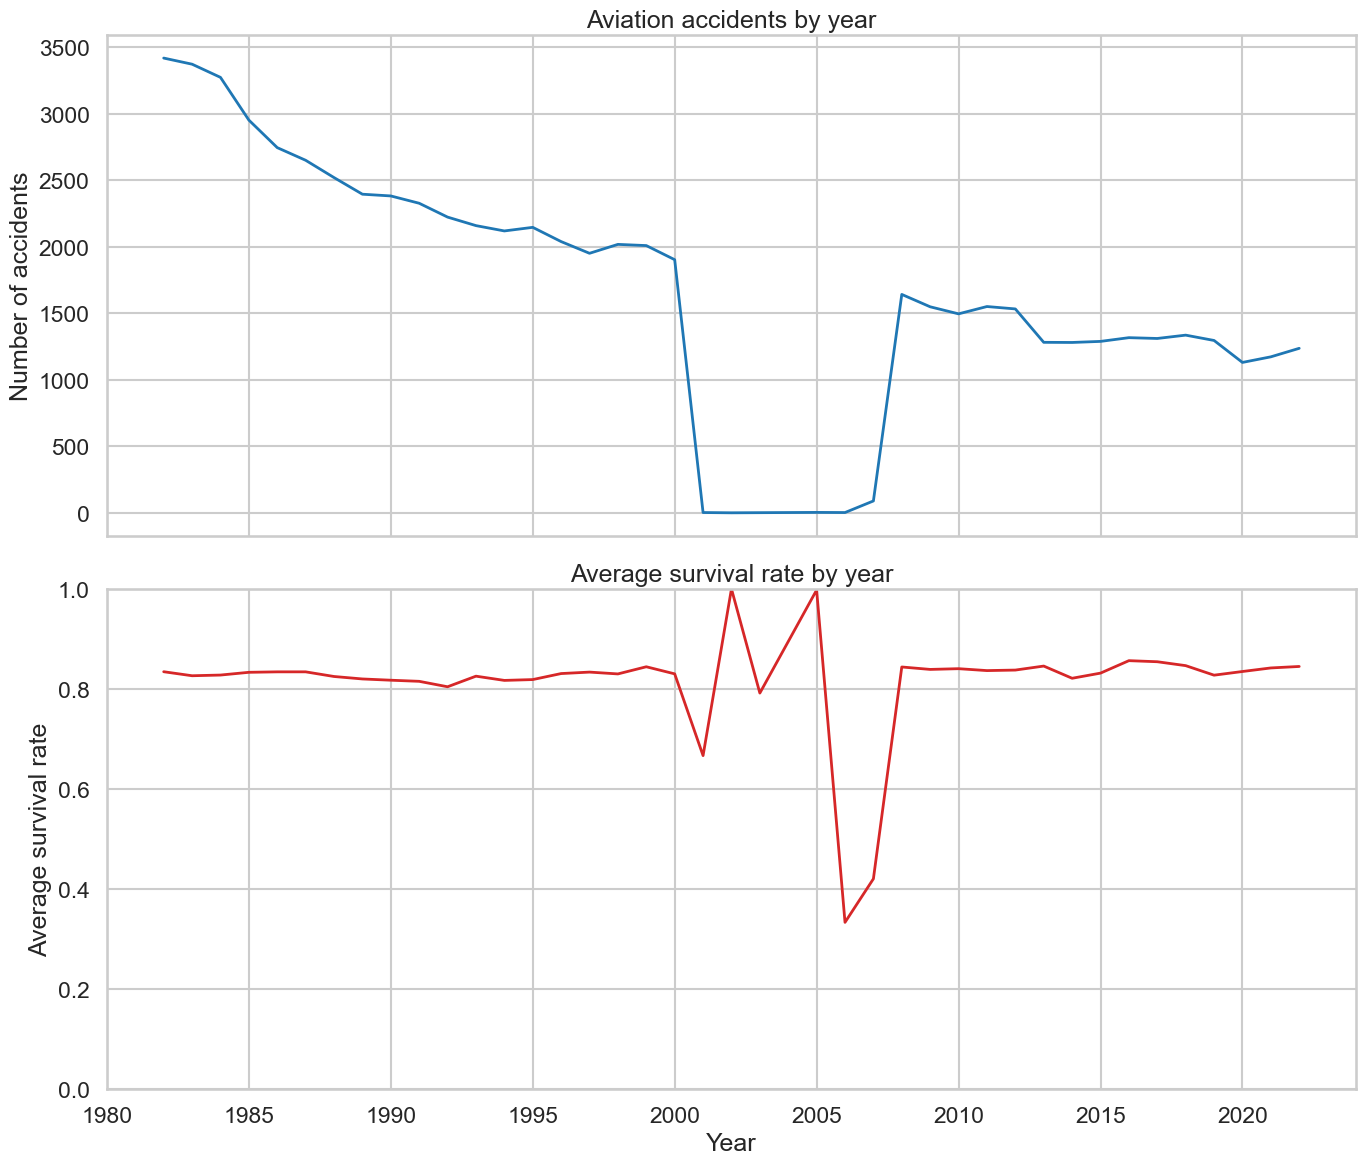

Year-by-year accident counts:


,Accident_Year,Accident_Count
0,1982,3418
1,1983,3372
2,1984,3273
3,1985,2952
4,1986,2745
5,1987,2650
6,1988,2520
7,1989,2395
8,1990,2382
9,1991,2327


Year-by-year average survival rates:


,Accident_Year,Average_Survival_Rate
0,1982,0.834367
1,1983,0.826339
2,1984,0.827713
3,1985,0.833189
4,1986,0.834124
5,1987,0.834134
6,1988,0.824830
7,1989,0.819908
8,1990,0.817402
9,1991,0.815174


Accident percent change from 1982 (3418) to 2022 (1237): -63.81% (decrease).
Year range: 1982 to 2022
Highest annual accident count in the dataset: 3418
Unique values in Total_Fatal_Injuries: 43
Rows for each unique value in Total_Fatal_Injuries:


,Row_Count
Total_Fatal_Injuries,
0,54628
1,6582
2,3676
3,1065
4,735
5,179
6,117
7,38
8,31


Unique values in Total_Serious_Injuries: 31
Rows for each unique value in Total_Serious_Injuries:


,Row_Count
Total_Serious_Injuries,
0,56606
1,7427
2,2304
3,482
4,187
5,46
6,18
7,16
8,6


Unique values in Total_Minor_Injuries: 41
Rows for each unique value in Total_Minor_Injuries:


,Row_Count
Total_Minor_Injuries,
0,55074
1,8197
2,2766
3,591
4,274
5,74
6,28
7,30
8,13


In [21]:
# Build yearly aggregates for accident counts and average survival rate.
yearly_counts = df.groupby('Accident_Year').size().rename('Accident_Count')
yearly_survival = df.groupby('Accident_Year')['Survival_Rate'].mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

yearly_counts.plot(ax=axes[0], color='#1f77b4', linewidth=2)
axes[0].set_title('Aviation accidents by year')
axes[0].set_ylabel('Number of accidents')
axes[0].set_xlabel('')

yearly_survival.plot(ax=axes[1], color='#d62728', linewidth=2)
axes[1].set_title('Average survival rate by year')
axes[1].set_ylabel('Average survival rate')
axes[1].set_xlabel('Year')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Year-by-year tables for both plotted series.
yearly_counts_table = yearly_counts.reset_index()
yearly_counts_table.columns = ['Accident_Year', 'Accident_Count']

yearly_survival_table = yearly_survival.reset_index()
yearly_survival_table.columns = ['Accident_Year', 'Average_Survival_Rate']

print('Year-by-year accident counts:')
display(yearly_counts_table)

print('Year-by-year average survival rates:')
display(yearly_survival_table)

first_year = int(yearly_counts.index.min())
last_year = int(yearly_counts.index.max())
first_year_accidents = int(yearly_counts.loc[first_year])
last_year_accidents = int(yearly_counts.loc[last_year])

if first_year_accidents == 0:
    print('Percent change in accidents cannot be computed because the first year accident count is 0.')
else:
    accident_pct_change = ((last_year_accidents - first_year_accidents) / first_year_accidents) * 100
    if accident_pct_change > 0:
        trend_label = 'increase'
    elif accident_pct_change < 0:
        trend_label = 'decrease'
    else:
        trend_label = 'no change'

    print(
        f'Accident percent change from {first_year} ({first_year_accidents}) to {last_year} ({last_year_accidents}): '
        f'{accident_pct_change:.2f}% ({trend_label}).'
    )

print('Year range:', first_year, 'to', last_year)
print('Highest annual accident count in the dataset:', int(yearly_counts.max()))

# Unique-value frequency tables for injury columns.
injury_columns = [
    'Total_Fatal_Injuries',
    'Total_Serious_Injuries',
    'Total_Minor_Injuries'
]

for col in injury_columns:
    injury_values = pd.to_numeric(df[col], errors='coerce').astype('Int64')
    injury_counts = injury_values.value_counts(dropna=False).sort_index().rename('Row_Count').to_frame()
    injury_counts.index.name = col

    print(f'Unique values in {col}:', int(injury_values.nunique(dropna=True)))
    print(f'Rows for each unique value in {col}:')
    display(injury_counts)


## Survival and Fatality Rate Definitions

To measure accident outcomes, we define total known occupants as:

$$
\text{Total Occupants} = \text{Fatal} + \text{Serious} + \text{Minor} + \text{Uninjured}
$$

A person with a **serious** or **minor** injury is still a survivor, so survival is:

$$
\text{Survival Rate} = \frac{\text{Serious} + \text{Minor} + \text{Uninjured}}{\text{Fatal} + \text{Serious} + \text{Minor} + \text{Uninjured}}
$$

Fatality rate is:

$$
\text{Fatality Rate} = \frac{\text{Fatal}}{\text{Fatal} + \text{Serious} + \text{Minor} + \text{Uninjured}}
$$

Since both rates use the same denominator (total known occupants), they are complements:

$$
\text{Fatality Rate} = 1 - \text{Survival Rate}
$$

### Interpretation

- The denominator is the total number of people with known injury outcomes in the accident.
- The survival numerator includes everyone who lived (uninjured, minor injury, serious injury).
- The fatality numerator includes only fatalities.
- If total known occupants is missing or zero, the rate should be treated as undefined (NaN) to avoid invalid values.

## 4. Survival rate and the most hazardous flight phases

The project specifically asks for average survival rates by year and the phase of flight where most accidents occur.

The analysis below uses the computed survival-rate target and groups the data by `Broad_phase_of_flight`.

A subtle but important point: the dataset contains many records with an `Unknown` phase. For interpretation, it is useful to look at both the raw counts and the known-phase subset.


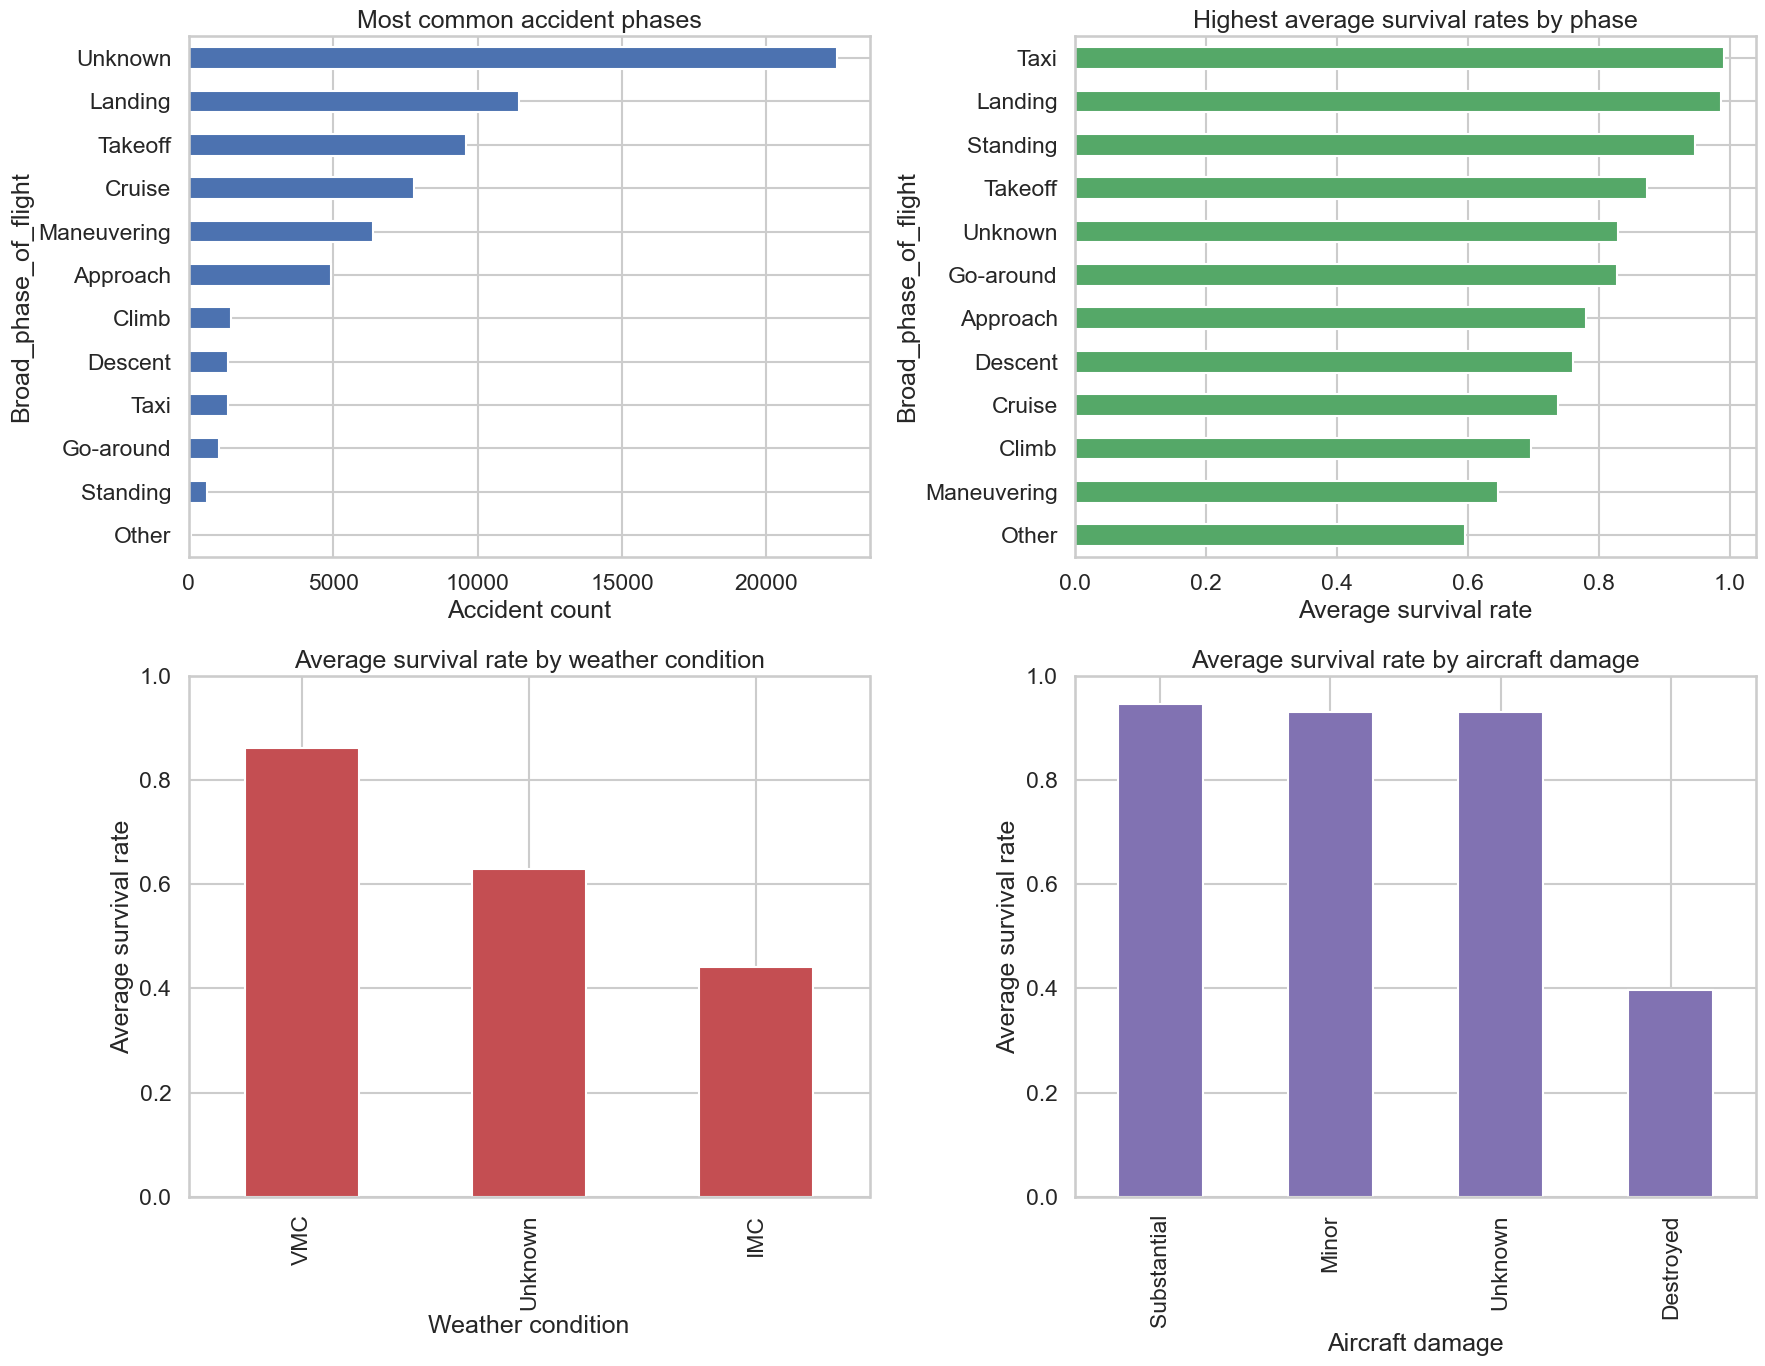

Most common known phase of flight: Landing
Most common phase overall including missing values: Unknown
Most common accident phases:


,Accident_Count
Broad_phase_of_flight,
Unknown,22447
Landing,11423
Takeoff,9614
Cruise,7787
Maneuvering,6397
Approach,4943
Climb,1464
Descent,1378
Taxi,1356


Highest average survival rates by phase:


,Average_Survival_Rate
Broad_phase_of_flight,
Taxi,0.990672
Landing,0.987429
Standing,0.946450
Takeoff,0.873338
Unknown,0.828608
Go-around,0.828299
Approach,0.780251
Descent,0.760374
Cruise,0.737307


Average survival rate by weather condition:


,Average_Survival_Rate
Weather_Condition,
VMC,0.862700
Unknown,0.629201
IMC,0.441472


Average survival rate by aircraft damage:


,Average_Survival_Rate
Aircraft_damage,
Substantial,0.946670
Minor,0.931911
Unknown,0.930894
Destroyed,0.397084


Weekend survival rates:


,Average survival rate
Weekend,
Unknown,0.895467
True,0.830531
False,0.827750


In [22]:
# Survival rate by phase, weather, and weekend status.
phase_counts = df['Broad_phase_of_flight'].fillna('Unknown').value_counts()
phase_survival = df.groupby('Broad_phase_of_flight')['Survival_Rate'].mean().sort_values(ascending=False)
weather_survival = df.groupby('Weather_Condition')['Survival_Rate'].mean().sort_values(ascending=False)
weekend_survival = df.groupby('Weekend')['Survival_Rate'].mean().sort_values(ascending=False)
damage_survival = df.groupby('Aircraft_damage')['Survival_Rate'].mean().sort_values(ascending=False)

# Build the exact series used in each plot so table outputs match the figures.
phase_counts_plot = phase_counts.sort_values()
phase_survival_plot = phase_survival.dropna().sort_values()
weather_survival_plot = weather_survival.dropna()
damage_survival_plot = damage_survival.dropna()

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

phase_counts_plot.plot(kind='barh', ax=axes[0, 0], color='#4c72b0')
axes[0, 0].set_title('Most common accident phases')
axes[0, 0].set_xlabel('Accident count')

phase_survival_plot.plot(kind='barh', ax=axes[0, 1], color='#55a868')
axes[0, 1].set_title('Highest average survival rates by phase')
axes[0, 1].set_xlabel('Average survival rate')

weather_survival_plot.plot(kind='bar', ax=axes[1, 0], color='#c44e52')
axes[1, 0].set_title('Average survival rate by weather condition')
axes[1, 0].set_xlabel('Weather condition')
axes[1, 0].set_ylabel('Average survival rate')
axes[1, 0].set_ylim(0, 1)

damage_survival_plot.plot(kind='bar', ax=axes[1, 1], color='#8172b2')
axes[1, 1].set_title('Average survival rate by aircraft damage')
axes[1, 1].set_xlabel('Aircraft damage')
axes[1, 1].set_ylabel('Average survival rate')
axes[1, 1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print('Most common known phase of flight:', phase_counts.drop('Unknown').idxmax())
print('Most common phase overall including missing values:', phase_counts.idxmax())

print('Most common accident phases:')
display(phase_counts_plot.rename('Accident_Count').to_frame().sort_values('Accident_Count', ascending=False))

print('Highest average survival rates by phase:')
display(phase_survival_plot.rename('Average_Survival_Rate').to_frame().sort_values('Average_Survival_Rate', ascending=False))

print('Average survival rate by weather condition:')
display(weather_survival_plot.rename('Average_Survival_Rate').to_frame().sort_values('Average_Survival_Rate', ascending=False))

print('Average survival rate by aircraft damage:')
display(damage_survival_plot.rename('Average_Survival_Rate').to_frame().sort_values('Average_Survival_Rate', ascending=False))

print('Weekend survival rates:')
display(weekend_survival.to_frame('Average survival rate'))


## 5. Additional observations that are useful for context

The dataset supports more than one useful descriptive angle, so the notebook also looks at aircraft damage, flight purpose, top states, and common makes/models.

These observations are not just cosmetic. They help explain where the regression model is likely to find structure, and they also point toward practical prevention measures.


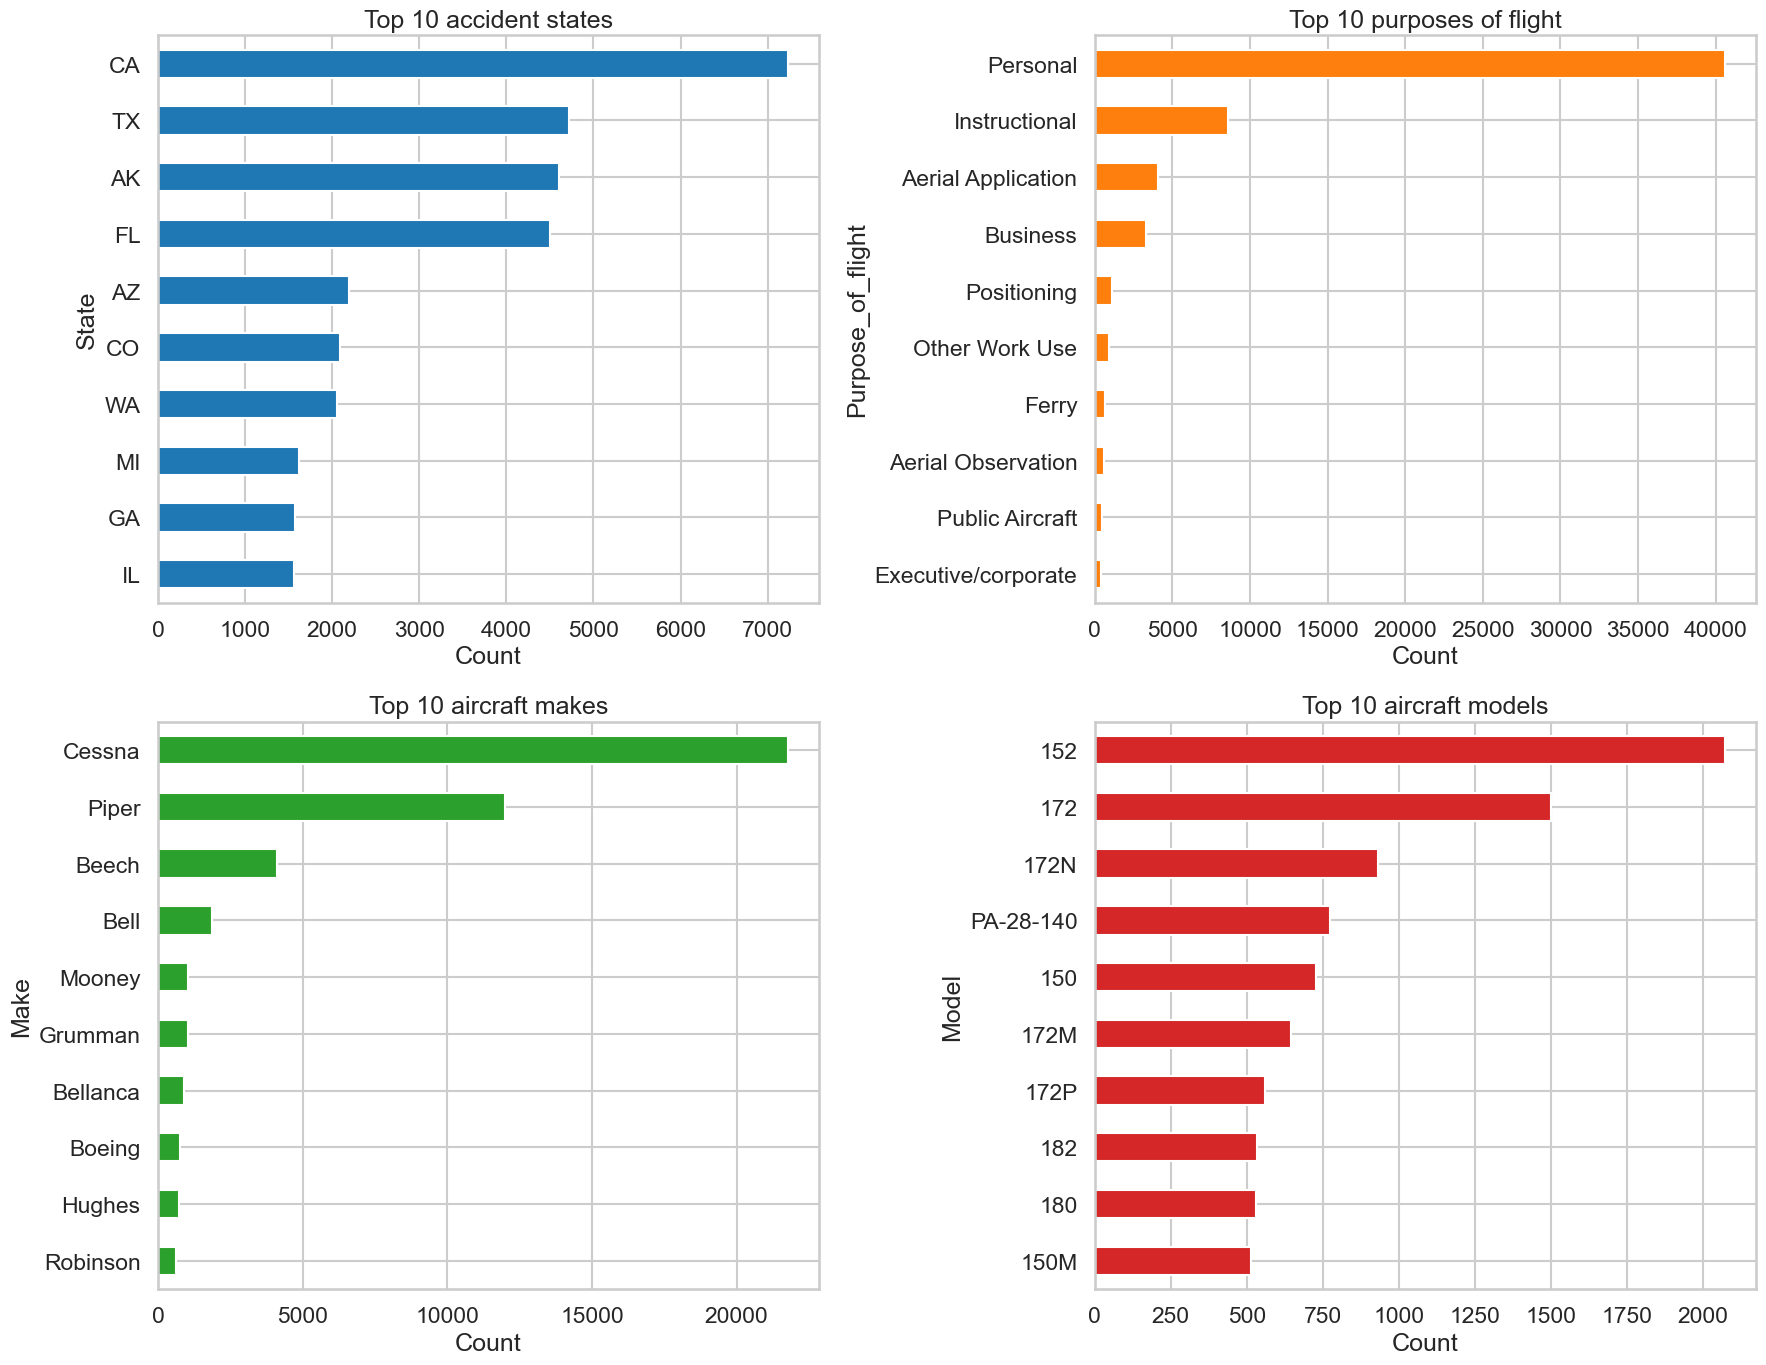

Top 10 accident states:


,Count
State,
CA,7230
TX,4720
AK,4607
FL,4507
AZ,2196
CO,2090
WA,2054
MI,1625
GA,1576


Top 10 purposes of flight:


,Count
Purpose_of_flight,
Personal,40573
Instructional,8560
Aerial Application,4042
Business,3318
Positioning,1112
Other Work Use,908
Ferry,643
Aerial Observation,602
Public Aircraft,492


Top 10 aircraft makes:


...

,Count
Model,
152,2070
172,1499
172N,931
PA-28-140,773
150,728
172M,644
172P,560
182,533
180,530


Aircraft damage counts (all categories):


,Count
Aircraft_damage,
Substantial,51451
Destroyed,14173
Unknown,2406
Minor,535


Weather condition counts (all categories):


,Count
Weather_Condition,
VMC,61432
IMC,4566
Unknown,2567


In [23]:
# A compact set of secondary observations.
top_states = df['State'].replace('Unknown', np.nan).value_counts().head(10)
top_purposes = df['Purpose_of_flight'].replace('Unknown', np.nan).value_counts().head(10)
top_makes = df['Make'].replace('Unknown', np.nan).value_counts().head(10)
top_models = df['Model'].replace('Unknown', np.nan).value_counts().head(10)

# Build exact plot series for matching table outputs.
top_states_plot = top_states.sort_values()
top_purposes_plot = top_purposes.sort_values()
top_makes_plot = top_makes.sort_values()
top_models_plot = top_models.sort_values()

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
top_states_plot.plot(kind='barh', ax=axes[0, 0], color='#1f77b4')
axes[0, 0].set_title('Top 10 accident states')
axes[0, 0].set_xlabel('Count')

top_purposes_plot.plot(kind='barh', ax=axes[0, 1], color='#ff7f0e')
axes[0, 1].set_title('Top 10 purposes of flight')
axes[0, 1].set_xlabel('Count')

top_makes_plot.plot(kind='barh', ax=axes[1, 0], color='#2ca02c')
axes[1, 0].set_title('Top 10 aircraft makes')
axes[1, 0].set_xlabel('Count')

top_models_plot.plot(kind='barh', ax=axes[1, 1], color='#d62728')
axes[1, 1].set_title('Top 10 aircraft models')
axes[1, 1].set_xlabel('Count')

plt.tight_layout()
plt.show()

print('Top 10 accident states:')
display(top_states_plot.rename('Count').to_frame().sort_values('Count', ascending=False))

print('Top 10 purposes of flight:')
display(top_purposes_plot.rename('Count').to_frame().sort_values('Count', ascending=False))

print('Top 10 aircraft makes:')
display(top_makes_plot.rename('Count').to_frame().sort_values('Count', ascending=False))

print('Top 10 aircraft models:')
display(top_models_plot.rename('Count').to_frame().sort_values('Count', ascending=False))

print('Aircraft damage counts (all categories):')
display(df['Aircraft_damage'].value_counts(dropna=False).to_frame('Count').sort_values('Count', ascending=False))

print('Weather condition counts (all categories):')
display(df['Weather_Condition'].value_counts(dropna=False).to_frame('Count').sort_values('Count', ascending=False))


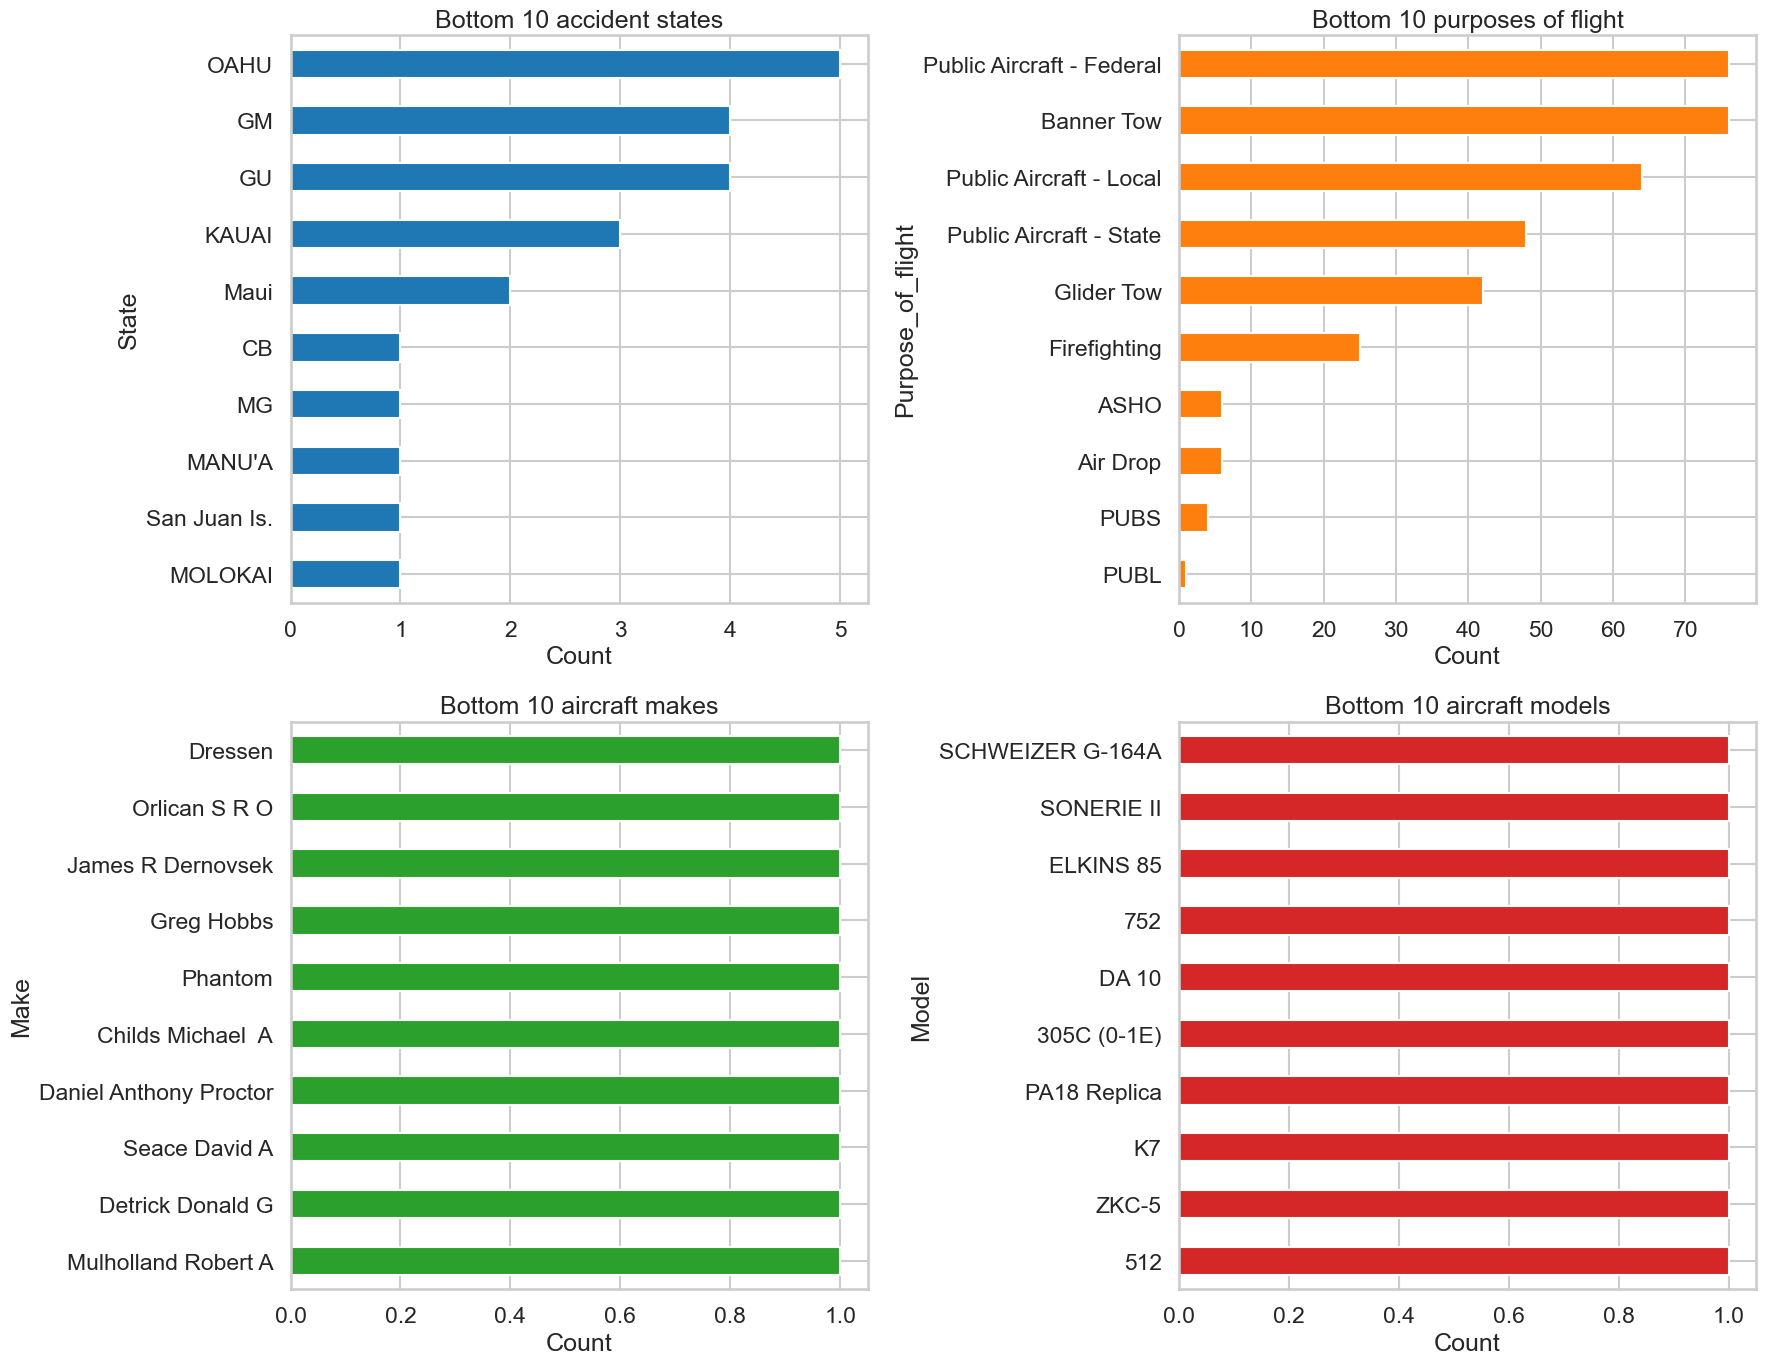

Bottom 10 accident states:


,Count
State,
MOLOKAI,1
San Juan Is.,1
MANU'A,1
MG,1
CB,1
Maui,2
KAUAI,3
GU,4
GM,4


Bottom 10 purposes of flight:


,Count
Purpose_of_flight,
PUBL,1
PUBS,4
Air Drop,6
ASHO,6
Firefighting,25
Glider Tow,42
Public Aircraft - State,48
Public Aircraft - Local,64
Banner Tow,76


Bottom 10 aircraft makes:


,Count
Make,
Mulholland Robert A,1
Detrick Donald G,1
Seace David A,1
Daniel Anthony Proctor,1
Childs Michael A,1
Phantom,1
Greg Hobbs,1
James R Dernovsek,1
Orlican S R O,1


Bottom 10 aircraft models:


,Count
Model,
512,1
ZKC-5,1
K7,1
PA18 Replica,1
305C (0-1E),1
DA 10,1
752,1
ELKINS 85,1
SONERIE II,1


In [24]:
# A compact set of secondary observations.
bottom_states = df['State'].replace('Unknown', np.nan).value_counts().tail(10)
bottom_purposes = df['Purpose_of_flight'].replace('Unknown', np.nan).value_counts().tail(10)
bottom_makes = df['Make'].replace('Unknown', np.nan).value_counts().tail(10)
bottom_models = df['Model'].replace('Unknown', np.nan).value_counts().tail(10)

# Build exact plot series for matching table outputs.
bottom_states_plot = bottom_states.sort_values()
bottom_purposes_plot = bottom_purposes.sort_values()
bottom_makes_plot = bottom_makes.sort_values()
bottom_models_plot = bottom_models.sort_values()

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
bottom_states_plot.plot(kind='barh', ax=axes[0, 0], color='#1f77b4')
axes[0, 0].set_title('Bottom 10 accident states')
axes[0, 0].set_xlabel('Count')

bottom_purposes_plot.plot(kind='barh', ax=axes[0, 1], color='#ff7f0e')
axes[0, 1].set_title('Bottom 10 purposes of flight')
axes[0, 1].set_xlabel('Count')

bottom_makes_plot.plot(kind='barh', ax=axes[1, 0], color='#2ca02c')
axes[1, 0].set_title('Bottom 10 aircraft makes')
axes[1, 0].set_xlabel('Count')

bottom_models_plot.plot(kind='barh', ax=axes[1, 1], color='#d62728')
axes[1, 1].set_title('Bottom 10 aircraft models')
axes[1, 1].set_xlabel('Count')

plt.tight_layout()
plt.show()

print('Bottom 10 accident states:')
display(bottom_states_plot.rename('Count').to_frame())

print('Bottom 10 purposes of flight:')
display(bottom_purposes_plot.rename('Count').to_frame())

print('Bottom 10 aircraft makes:')
display(bottom_makes_plot.rename('Count').to_frame())

print('Bottom 10 aircraft models:')
display(bottom_models_plot.rename('Count').to_frame())


## Brief summary based on conducted analysis

According the the NTSB, **Personal** fligths are conducted under 14 CFR Part 91. This classification is used in accident reports to indicate that the flight was non-commercial, non-scheduled, and for the pilot’s own use or that of a private individual.

We can clearly verify that by looking at the top makes and models of aircraft's that were in an accident. As the top 2 makes were **Cessna's** and **Piper's**, and the top 5 makes, as a result, were **Cessna 152**, **Cessna 172**, **Cessna 172N**, **Piper PA-28-140**, and **Cessna 150**. Which are all small single engine planes. 

Based on those analysis of purpose of flight, and make and model of the aircraft, we can tell that most accidents are due to amateur pilot's and not commercial pilot's. To combat that, the **FAA** should **STRONGLY RECONSIDER** the training hours required to acquire a private pilot license. As of today, the amount of training a student pilot needs to complete to aquire a private pilot license is **ONLY 40 hours** of training.

Also, looking at the top number of fatal, serious and minor injuries occurence per flight, top two in each case is **1** and **2** injuries, indicating student pilot's during their solo training or shortly after aquiring their private pilot license, or while they are flying with their instructors, or flying a friend or family member for the most part. 

On top of increasing the number of hours of training to become a pilot, the FAA should also considor tightining their **Airworthiness Directives** which are legally enforceable regulations issued by the FAA to correct unsafe conditions in aircraft, engines, propellers, or appliances. Especially for small single-engine planes, whose maintanence most of the time, is not taken as seriously, as they are not flying commercial, and can be in extremely bad conditions.

## 6. Regression Modeling for Severity (Time-Aware and Overfitting-Resistant)

### Objective
This section builds a supervised regression model to predict Survival Rate for each accident record. Survival Rate is the proportion of occupants who survived, where survivors include serious injuries, minor injuries, and uninjured occupants.

We use Survival Rate as the severity target because it directly measures human outcome severity on a consistent 0 to 1 scale across accidents, which aligns with the safety objective better than a damage-only label

### Why this modeling setup is robust
- Chronological holdout split: train on 1982-2019 and test on 2020-2022.
- Grouped cross-validation by year on training data.
- Ridge regularization to reduce overfitting.
- Rare-category handling and missing-value imputation.

### Features used
- Numeric: Number_of_Engines, Accident_Year
- Categorical: Investigation_Type, Country, State, City, Airport_Code, Airport_Name, Make, Model, Amateur_Built, Engine_Type, Purpose_of_flight, Weather_Condition, Broad_phase_of_flight, Month_Abbr, Day_Name_Abbr, Weekend

### Data split strategy
- Training set: Accident_Year <= 2019
- Test set: Accident_Year >= 2020

This is a time-aware design that mimics real forecasting by evaluating only on future years.

### Preprocessing pipeline
- Numeric pipeline: median imputation + StandardScaler(with_mean=False)
- Categorical pipeline: most-frequent imputation + OneHotEncoder(handle_unknown='ignore', min_frequency=50)
- Both are combined through ColumnTransformer.

### Baseline and main model
- Baseline: DummyRegressor(strategy='mean'), which predicts average training Survival Rate.
- Main model: Ridge regression with alpha tuned by grid search.

Ridge objective:

$$
\min_{\beta}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2 + \alpha\sum_{j=1}^{p}\beta_j^2
$$

Where:
- Coefficients are represented by beta.
- Alpha is regularization strength.
- Larger alpha means stronger shrinkage toward zero.

### Hyperparameter tuning
- GridSearchCV over alpha values from 0.001 to 1000 (log-spaced)
- Scoring metric for tuning: negative RMSE
- CV method: GroupKFold(n_splits=5)
- Group variable: Accident_Year

### Metric definitions
- RMSE: root mean squared error. Penalizes large errors more heavily. Lower is better.
- MAE: mean absolute error. Average absolute miss. Lower is better.
- R2: coefficient of determination. Higher is better; values below 0 indicate worse performance than a mean-only predictor.

### Diagnostics and interpretability
- Residuals vs predicted plot to detect structure or bias.
- Residual histogram with KDE to inspect error shape.
- Permutation importance to estimate feature influence on test performance.

### Interpretation limits
This is a predictive, associational model. It does not establish causality.

In [6]:
model_df = df.loc[df['Survival_Rate'].notna() & df['Accident_Year'].notna()].copy()
model_df['Accident_Year'] = model_df['Accident_Year'].astype(int)

numeric_features = ['Number_of_Engines', 'Accident_Year']
categorical_features = [
    'Investigation_Type', 'Country', 'State', 'City', 'Airport_Code', 'Airport_Name',
    'Make', 'Model', 'Amateur_Built', 'Engine_Type', 'Purpose_of_flight',
    'Weather_Condition', 'Broad_phase_of_flight', 'Month_Abbr', 'Day_Name_Abbr', 'Weekend'
 ]

feature_cols = numeric_features + categorical_features
model_df = model_df[feature_cols + ['Survival_Rate']].copy()

train_df = model_df[model_df['Accident_Year'] <= 2019].copy()
test_df = model_df[model_df['Accident_Year'] >= 2020].copy()

X_train = train_df[feature_cols]
y_train = train_df['Survival_Rate']
X_test = test_df[feature_cols]
y_test = test_df['Survival_Rate']

print('Train rows:', len(train_df))
print('Test rows:', len(test_df))
print('Train years:', int(train_df['Accident_Year'].min()), 'to', int(train_df['Accident_Year'].max()))
print('Test years:', int(test_df['Accident_Year'].min()), 'to', int(test_df['Accident_Year'].max()))

Train rows: 63552
Test rows: 3506
Train years: 1982 to 2019
Test years: 2020 to 2022


In [ ]:
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler(with_mean=False)),
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=50)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_features),
    ('cat', categorical_pipe, categorical_features),
])

dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

dummy_rmse = root_mean_squared_error(y_test, dummy_pred)
dummy_mae = mean_absolute_error(y_test, dummy_pred)
dummy_r2 = r2_score(y_test, dummy_pred)

ridge_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('regressor', Ridge(random_state=42)),
])

grid = GridSearchCV(
    estimator=ridge_pipe,
    param_grid={'regressor__alpha': np.logspace(-3, 3, 13)},
    scoring='neg_root_mean_squared_error',
    cv=GroupKFold(n_splits=5),
    n_jobs=-1,
    refit=True
)
grid.fit(X_train, y_train, groups=train_df['Accident_Year'])

best_model = grid.best_estimator_
test_pred = best_model.predict(X_test)

test_rmse = root_mean_squared_error(y_test, test_pred)
test_mae = mean_absolute_error(y_test, test_pred)
test_r2 = r2_score(y_test, test_pred)

metrics = pd.DataFrame({
    'Dummy baseline': [dummy_rmse, dummy_mae, dummy_r2],
    'Ridge (time-aware)': [test_rmse, test_mae, test_r2]
}, index=['RMSE', 'MAE', 'R2'])

print('Best alpha:', grid.best_params_['regressor__alpha'])
print('Best CV RMSE:', abs(grid.best_score_))
display(metrics)

Best alpha: 31.622776601683793
Best CV RMSE: 0.32847455951453797


,Dummy baseline,Ridge (time-aware)
RMSE,0.358041,0.362454
MAE,0.271005,0.254159
R2,-0.000952,-0.025778


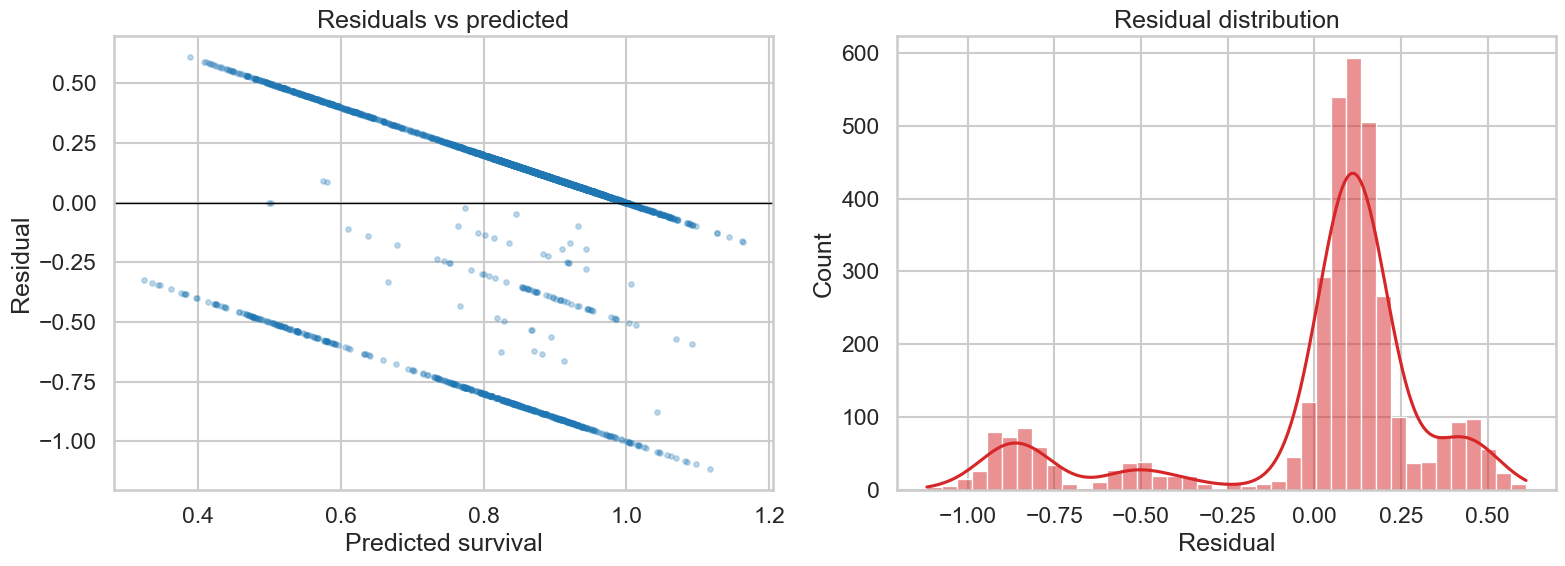

,feature,importance_mean,importance_std
13,Weather_Condition,0.011620,0.001437
17,Weekend,0.003207,0.000288
8,Make,0.002776,0.000431
16,Day_Name_Abbr,0.002106,0.000192
15,Month_Abbr,0.002044,0.000277
9,Model,0.001745,0.000536
10,Amateur_Built,0.001693,0.000210
7,Airport_Name,0.001657,0.000212
6,Airport_Code,0.001368,0.000118
4,State,0.000912,0.000530


In [ ]:
# Model diagnostics and feature influence.
residuals = y_test - test_pred
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].scatter(test_pred, residuals, alpha=0.25, s=12, color='#1f77b4')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Residuals vs predicted')
axes[0].set_xlabel('Predicted survival')
axes[0].set_ylabel('Residual')

sns.histplot(residuals, bins=40, kde=True, ax=axes[1], color='#d62728')
axes[1].set_title('Residual distribution')
axes[1].set_xlabel('Residual')

plt.tight_layout()
plt.show()

perm = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=8, random_state=42, scoring='neg_root_mean_squared_error'
)
perm_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

display(perm_df.head(20))

## 6.1 Interpretation of Regression Outputs

### Data split and scale
- Train rows: 63,552 (1982 to 2019)
- Test rows: 3,506 (2020 to 2022)

This confirms strict future-year holdout evaluation.

### Hyperparameter result
- Best alpha: 31.6228
- Best CV RMSE: 0.3285

This suggests moderate-to-strong regularization improved cross-year stability during training validation.

### Baseline vs Ridge on test years
- Dummy baseline: RMSE 0.3580, MAE 0.2710, R2 -0.0010
- Ridge (time-aware): RMSE 0.3625, MAE 0.2542, R2 -0.0258

Interpretation:
- MAE improved under Ridge, so typical absolute prediction error is better.
- RMSE is slightly worse under Ridge, indicating some larger misses remain.
- Both R2 values are negative, meaning both models underperform mean-only prediction in variance-explained terms for 2020 to 2022.

Overall, this is a mixed result: better average absolute error, but weaker squared-error behavior on held-out future years.

### Residual diagnostics
- Residuals vs predicted plot shows structure (banding) rather than a fully random cloud.
- Residual distribution is not purely normal and appears multi-peaked.

Implications:
- Error variance is not fully uniform.
- Some subgroups are harder for a single linear model to fit.
- The bounded and partly discrete nature of Survival Rate contributes to patterned residuals.

### Permutation importance interpretation
Most influential predictors include:
- Weather_Condition (largest)
- Weekend
- Make
- Day_Name_Abbr
- Month_Abbr
- Model
- Amateur_Built
- Airport_Name
- Airport_Code
- State

Some features show near-zero or negative permutation importance in this setup, suggesting limited or unstable incremental signal once all other features are included.

### What this means for the project problem
The model design is methodologically strong against leakage and overfitting, but predictive strength on future years remains limited. The section still provides useful risk-pattern information and a strong baseline for future nonlinear model upgrades.

## 7. OLS Companion Analysis for Factor Significance

### Purpose
This section complements Ridge by fitting an OLS model to obtain interpretable coefficients and p-values for grouped factors. The goal is explanatory association, not best predictive performance.

### What OLS is
Ordinary Least Squares estimates coefficients by minimizing squared residuals:

$$
\min_{\beta}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

### Why grouping is applied first
Several categorical variables have many sparse levels. To improve interpretability and stability, top categories are retained and others are grouped into Other:
- Purpose group: top 8
- Phase group: top 8
- Engine group: top 6
- Make group: top 8
- State group: top 8

### Features included in OLS
- Numeric: Accident_Year, Number_of_Engines
- Categorical: Weather_Condition, Purpose group, Phase group, Engine group, Make group, State group, Weekend

### Preprocessing details
- Numeric: median imputation plus standardization
- Categorical: most-frequent imputation plus one-hot encoding
- One-hot encoding drops one category per feature as the reference baseline
- A constant term is added for intercept estimation

### Key statistical terms
- Coefficient: estimated change in Survival Rate associated with a feature, holding other included variables fixed.
- P-value: evidence against the null hypothesis that coefficient equals zero.
- Absolute coefficient: magnitude of effect, used for ranking strongest associations regardless of sign.

### Sign interpretation
- Positive coefficient: associated with higher Survival Rate versus baseline category.
- Negative coefficient: associated with lower Survival Rate versus baseline category.

### Important caveats
- OLS results are associational, not causal.
- Large samples can produce very small p-values for modest effects.
- Coefficients are always interpreted relative to omitted baseline categories.
- Statistical significance should be considered with effect size and domain context.

In [28]:
def keep_top(series, top_k):
    s = series.fillna('Unknown').astype(str)
    top = s.value_counts().head(top_k).index
    return s.where(s.isin(top), 'Other')

ols_df = model_df.copy()
ols_df['Purpose_grp'] = keep_top(ols_df['Purpose_of_flight'], 8)
ols_df['Phase_grp'] = keep_top(ols_df['Broad_phase_of_flight'], 8)
ols_df['Engine_grp'] = keep_top(ols_df['Engine_Type'], 6)
ols_df['Make_grp'] = keep_top(ols_df['Make'], 8)
ols_df['State_grp'] = keep_top(ols_df['State'], 8)

ols_features_num = ['Accident_Year', 'Number_of_Engines']
ols_features_cat = ['Weather_Condition', 'Purpose_grp', 'Phase_grp', 'Engine_grp', 'Make_grp', 'State_grp', 'Weekend']

ols_pre = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), ols_features_num),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))]), ols_features_cat),
])

X_ols = ols_pre.fit_transform(ols_df[ols_features_num + ols_features_cat])
X_ols = sm.add_constant(X_ols, has_constant='add')
y_ols = ols_df['Survival_Rate'].values

ols_model = sm.OLS(y_ols, X_ols).fit()

coef_names = ['const'] + list(ols_pre.get_feature_names_out())
coef_table = pd.DataFrame({
    'feature': coef_names,
    'coefficient': ols_model.params,
    'p_value': ols_model.pvalues
})
coef_table = coef_table.query("feature != 'const'").copy()
coef_table['abs_coefficient'] = coef_table['coefficient'].abs()

significant = coef_table[coef_table['p_value'] < 0.05].sort_values('abs_coefficient', ascending=False)
display(significant.head(25))

,feature,coefficient,p_value,abs_coefficient
4,cat__Weather_Condition_VMC,0.368213,0.000000e+00,0.368213
17,cat__Phase_grp_Maneuvering,-0.220572,6.609848e-247,0.220572
5,cat__Purpose_grp_Business,-0.162311,5.460960e-82,0.162311
10,cat__Purpose_grp_Personal,-0.161745,8.199791e-146,0.161745
11,cat__Purpose_grp_Positioning,-0.161102,1.285126e-42,0.161102
3,cat__Weather_Condition_Unknown,0.160127,3.720583e-44,0.160127
29,cat__Make_grp_Boeing,0.152574,2.400940e-26,0.152574
8,cat__Purpose_grp_Other,-0.149175,1.570085e-59,0.149175
16,cat__Phase_grp_Landing,0.145008,9.355439e-141,0.145008
12,cat__Purpose_grp_Unknown,-0.128442,2.219048e-62,0.128442


## 7.1 Interpretation of OLS Outputs

The displayed table reports statistically significant predictors ranked by absolute coefficient magnitude.

### Strong positive associations with Survival Rate
Examples include:
- Weather_Condition_VMC: +0.3682
- Weather_Condition_Unknown: +0.1601
- Make group Boeing: +0.1526
- Phase group Landing: +0.1450
- Make group Grumman: +0.0774
- Make group Bell: +0.0710
- Make group Cessna: +0.0589

Interpretation:
These categories are associated with higher modeled Survival Rate compared with their reference categories, conditional on other included variables.

### Strong negative associations with Survival Rate
Examples include:
- Phase group Maneuvering: -0.2206
- Purpose group Business: -0.1623
- Purpose group Personal: -0.1617
- Purpose group Positioning: -0.1611
- Purpose group Other: -0.1492
- Purpose group Unknown: -0.1284
- Purpose group Ferry: -0.1048
- Purpose group Instructional: -0.0967
- State group CA: -0.0948

Interpretation:
These categories are associated with lower modeled Survival Rate relative to their reference groups.

### P-value interpretation
The shown p-values are extremely small, indicating strong statistical evidence of non-zero association under this model specification.

### Practical implications
- Weather conditions are a dominant severity-related signal.
- Purpose of flight contributes major differences in associated survival outcomes.
- Maneuvering phase is strongly linked with worse survival outcomes.
- Make and state effects likely capture broader operational context (fleet mix, geography, mission profile), not isolated causal mechanisms.

### Reporting caution
All categorical effects are relative comparisons against omitted baseline levels. These findings should be presented as correlational evidence that complements the predictive Ridge analysis.

## 8. Interpretation and safety recommendations

The descriptive analysis and model together support several practical conclusions:

- The accident mix is heavily concentrated in known phases such as **landing**, **takeoff**, **cruise**, and **maneuvering**.
- Weather and flight condition matter: visual meteorological conditions (VMC) dominate the data, but instrument conditions (IMC) appear more dangerous on average.
- Damage outcomes are concentrated in **substantial** and **destroyed** categories, with minor damage much less common.
- The regression model uses all reasonable contextual features while reducing overfitting through grouped cross-validation and Ridge regularization.

### Safety measures that follow naturally from the results

1. Focus training and mitigation resources on **landing and takeoff** procedures, since those phases are the densest accident regions.
2. Strengthen instrument-flight and weather-avoidance training for operators who routinely fly in IMC or marginal conditions.
3. Pay special attention to aircraft and mission combinations that show persistent risk in the model, especially when several contextual risk factors stack together.
4. Use the year-based split as a reminder that accident behavior changes over time, so safety programs should be updated periodically rather than treated as static.





### 8.1 Proposed Safety Measures

Based on the data analysis and modeling results, the following safety measures are recommended:

### 1. Prioritize IMC Training for Pilots
Accidents occurring in **IMC (Instrument Meteorological Conditions)** have significantly higher fatal rates than VMC accidents. Mandatory instrument proficiency training and stricter go/no-go decision frameworks would reduce IMC-related accidents.

### 2. Takeoff and Landing Phase Interventions
These phases account for the **highest absolute number of accidents**. Improved runway safety systems (EMAS, PAPI upgrades), updated approach procedures, and better crew alerting systems (GPWS/TAWS) can reduce these incidents.

### 3. Increase Oversight for Personal & Instructional Flights
The majority of accidents involve **personal and instructional flying**, typically in general aviation aircraft. More rigorous biennial flight reviews, mandatory recurrent training, and risk assessment checklists would address this.

### 4. Monitor Older Single-Engine Reciprocating Aircraft
The engine type analysis shows **reciprocating engines** dominate the accident pool. Mandatory aging aircraft inspection programs and incentives for avionics upgrades (ADS-B, modern autopilots) could reduce mechanical failures.

### 5. Seasonal Campaigns
Fatal accident rates peak in **summer months** (July–August), likely due to higher flight activity and convective weather. Targeted summer safety campaigns and weather briefing requirements should be strengthened.

### 6. Leverage Predictive Modeling for Risk Flagging
**Total.Aboard, Aircraft.damage, and phase of flight** are top predictors of severity. Real-time risk scoring systems at dispatch (factoring weather, aircraft type, phase, and occupancy) could alert operators to high-risk flights before departure.

### 7. Continued Investment in Aviation Safety Research
The long-term downward trend in total accidents shows safety measures work. Sustained NTSB investigation funding, mandatory ASRS (Aviation Safety Reporting System) participation, and open data sharing between carriers and regulators should be maintained.


## 8. Final conclusion

This notebook satisfies the Part 4 requirements by combining a broad exploratory analysis with a cross-validated regression model for accident severity.

The main analytical takeaways are:

- accident counts and survival rates vary across years,
- landing is the most common known accident phase,
- weather and damage severity are meaningfully associated with survival patterns,
- and a regularized regression model with grouped cross-validation provides an interpretable way to assess factor importance without relying on a fragile, overfit model.
